# Proyecto 1 — Semana 6: Transformer desde cero

**Curso:** Deep Learning  
**Valor:** 8% de la nota del curso  
**Entrega:** Notebook ejecutado + video de 3 minutos (ver instrucciones al final)

---

## Descripcion general

Este proyecto tiene cuatro partes:

**Parte 1 (40 pts):** Implementar un Transformer Encoder desde cero con PyTorch para clasificacion de sentimientos sobre el corpus SST-2 (resenas de peliculas).

**Parte 2 (25 pts):** Implementar un Mini-GPT decoder-only desde cero, reutilizando los mismos bloques del encoder pero con mascara causal, para modelado de lenguaje sobre el mismo corpus.

**Parte 3 (15 pts):** Artifact de visualizacion interactivo que muestra los mapas de atencion del encoder y la generacion de texto del Mini-GPT.

**Parte 4 (20 pts):** Video de 3 minutos donde el grupo explica su artifact, muestra el Mini-GPT generando texto en vivo, y responde las preguntas de analisis.

## Reglas generales

- Todo el codigo de los bloques marcados debe implementarse con **tensores PyTorch puros**. No se permite `nn.MultiheadAttention`, `nn.TransformerEncoder`, ni ninguna capa de alto nivel que implemente la arquitectura por usted.
- Puede usar `nn.Parameter` y `torch.optim.Adam` para el entrenamiento.
- Puede usar `loss.backward()` y `optimizer.step()` — el backward automatico de PyTorch es valido en este proyecto.
- El corpus se descarga automaticamente desde GitHub al ejecutar el Bloque 0.
- La celda de verificacion automatica al final califica los 65 puntos de codigo.

---
## Bloque 0: Imports, corpus y vocabularios (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random, hashlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
random.seed(42)
print(f'PyTorch: {torch.__version__}')


PyTorch: 2.13.0+cu130


In [2]:
# Corpus SST-2 desde GitHub
import urllib.request, random
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/train.tsv', 'sst2_train.tsv')
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/dev.tsv', 'sst2_dev.tsv')

def filter_data(path, min_len=3, max_len=15):
    out = []
    with open(path) as f:
        for l in f:
            parts = l.strip().split('\t')
            if len(parts) != 2: continue
            text, label = parts[0].lower(), int(parts[1])
            if min_len <= len(text.split()) <= max_len:
                out.append((text, label))
    return out

random.seed(42)
train_all = filter_data('sst2_train.tsv')
dev_all   = filter_data('sst2_dev.tsv')
random.shuffle(train_all)
TRAIN_CLS = train_all[:300]
DEV_CLS   = dev_all[:100]
GPT_TRAIN = [t for t,_ in train_all[:400]]
print(f'Clasificacion - Train: {len(TRAIN_CLS)}, Dev: {len(DEV_CLS)}')
print(f'GPT corpus: {len(GPT_TRAIN)} oraciones')
print(f'Ejemplo clasificacion: {TRAIN_CLS[0]}')
print(f'Ejemplo GPT: {GPT_TRAIN[0]}')


Clasificacion - Train: 300, Dev: 100
GPT corpus: 400 oraciones
Ejemplo clasificacion: ("the movie 's thesis elegant technology for the masses is surprisingly refreshing", 1)
Ejemplo GPT: the movie 's thesis elegant technology for the masses is surprisingly refreshing


In [3]:
# Vocabulario para clasificacion (con token CLS)
PAD, UNK, CLS = '<PAD>', '<UNK>', '<CLS>'
SPECIAL = [PAD, UNK, CLS]
words_cls = Counter()
for t,_ in TRAIN_CLS: words_cls.update(t.split())
vocab_cls = SPECIAL + [w for w,c in words_cls.most_common() if c >= 2]
w2i_cls = {w:i for i,w in enumerate(vocab_cls)}
i2w_cls = {i:w for w,i in w2i_cls.items()}
V_CLS = len(vocab_cls)
MAX_LEN_CLS = 16  # CLS + hasta 15 tokens

# Vocabulario para GPT (con BOS y EOS)
BOS, EOS, PAD_G, UNK_G = '<BOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL_G = [PAD_G, UNK_G, BOS, EOS]
words_gpt = Counter()
for t in GPT_TRAIN: words_gpt.update(t.split())
vocab_gpt = SPECIAL_G + [w for w,c in words_gpt.most_common() if c >= 2]
w2i_gpt = {w:i for i,w in enumerate(vocab_gpt)}
i2w_gpt = {i:w for w,i in w2i_gpt.items()}
V_GPT = len(vocab_gpt)
MAX_LEN_GPT = 14  # BOS + hasta 12 tokens + EOS

print(f'Vocab clasificacion: {V_CLS}, MAX_LEN: {MAX_LEN_CLS}')
print(f'Vocab GPT: {V_GPT}, MAX_LEN: {MAX_LEN_GPT}')

def tokenize_cls(text, max_len=MAX_LEN_CLS):
    toks = [CLS] + [w if w in w2i_cls else UNK for w in text.split()[:max_len-1]]
    idxs = [w2i_cls[t] for t in toks]
    mask = [True]*len(idxs) + [False]*(max_len-len(idxs))
    while len(idxs) < max_len: idxs.append(w2i_cls[PAD])
    return torch.tensor(idxs[:max_len]), torch.tensor(mask[:max_len])

def tokenize_gpt(text, max_len=MAX_LEN_GPT):
    toks = [BOS]+[w if w in w2i_gpt else UNK_G for w in text.split()[:max_len-2]]+[EOS]
    idxs = [w2i_gpt[t] for t in toks]
    while len(idxs) < max_len: idxs.append(w2i_gpt[PAD_G])
    return torch.tensor(idxs[:max_len])

# Verificacion de tokenizacion
idxs_test, mask_test = tokenize_cls(TRAIN_CLS[0][0])
print(f'Ejemplo tokenizado: {[i2w_cls[i.item()] for i in idxs_test[:8]]}')
print(f'Mascara: {mask_test[:8].tolist()}')


Vocab clasificacion: 328, MAX_LEN: 16
Vocab GPT: 432, MAX_LEN: 14
Ejemplo tokenizado: ['<CLS>', 'the', 'movie', "'s", '<UNK>', 'elegant', '<UNK>', 'for']
Mascara: [True, True, True, True, True, True, True, True]


In [4]:
# Dimensiones del modelo (fijas para autograder)
D_MODEL = 32   # dimension central de la arquitectura
D_FF    = 64   # dimension interna del FFN
N_HEADS = 2    # numero de cabezas de atencion
D_K     = D_MODEL // N_HEADS  # dimension por cabeza = 16

# Positional encoding (dado, no modificar)
def make_positional_encoding(max_len, d_model):
    """
    Genera la matriz de positional encoding de Vaswani et al. 2017.
    PE(t, 2i)   = sin(t / 10000^(2i/d_model))
    PE(t, 2i+1) = cos(t / 10000^(2i/d_model))

    Parametros
    ----------
    max_len : int, largo maximo de secuencia
    d_model : int, dimension del modelo

    Retorna
    -------
    pe : torch.Tensor de forma (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

PE_CLS = make_positional_encoding(MAX_LEN_CLS, D_MODEL)
PE_GPT = make_positional_encoding(MAX_LEN_GPT, D_MODEL)
print(f'PE_CLS: {PE_CLS.shape}, PE_GPT: {PE_GPT.shape}')

# Mascara causal para GPT (triangular superior = True = enmascarado)
CAUSAL_MASK = torch.triu(torch.ones(MAX_LEN_GPT, MAX_LEN_GPT), diagonal=1).bool()
print(f'CAUSAL_MASK shape: {CAUSAL_MASK.shape}')
print('Primeras 4 filas de la mascara causal:')
print(CAUSAL_MASK[:4, :6].int())


PE_CLS: torch.Size([16, 32]), PE_GPT: torch.Size([14, 32])
CAUSAL_MASK shape: torch.Size([14, 14])
Primeras 4 filas de la mascara causal:
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1]], dtype=torch.int32)


---
## Parte 1: Transformer Encoder para clasificacion de sentimientos

Implemente el encoder Transformer completo como una clase `nn.Module`. El modelo usa un token especial `[CLS]` en la primera posicion: su representacion despues del bloque encoder se usa para clasificar la oracion como positiva (1) o negativa (0).

**Arquitectura:**
```
texto -> tokenize_cls -> E[idxs] + PE  ->  [Multi-Head Self-Attention]
                                            [Add & LayerNorm]
                                            [Feed-Forward por posicion]
                                            [Add & LayerNorm]
                                        ->  representacion CLS -> W_cls -> logits
```

**Parametros que debe declarar en `__init__` como `nn.Parameter`:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{cls}, d_{model})$ | Matriz de embeddings |
| `WQ`, `WK`, `WV` | $(d_{model}, d_{model})$ | Proyecciones de atencion |
| `WO` | $(d_{model}, d_{model})$ | Proyeccion de salida multi-head |
| `gamma1`, `beta1` | $(d_{model},)$ | LayerNorm 1 |
| `W1` | $(d_{model}, d_{ff})$ | FFN capa 1 |
| `bias1` | $(d_{ff},)$ | Bias FFN capa 1 |
| `W2` | $(d_{ff}, d_{model})$ | FFN capa 2 |
| `bias2` | $(d_{model},)$ | Bias FFN capa 2 |
| `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm 2 |
| `Wcls` | $(d_{model}, 2)$ | Clasificador sobre token CLS |
| `bcls` | $(2,)$ | Bias clasificador |

In [5]:
def layer_norm(x, gamma, beta, eps=1e-5):
    """
    Layer Normalization sobre la ultima dimension.

    Parametros
    ----------
    x     : Tensor de forma (..., d_model)
    gamma : Tensor de forma (d_model,) — escala aprendible
    beta  : Tensor de forma (d_model,) — desplazamiento aprendible
    eps   : float, estabilidad numerica

    Retorna
    -------
    Tensor de la misma forma que x, normalizado por media y std
    sobre la dimension d_model.
    """
    # media y varianza sobre la ultima dimension (d_model), por fila
    mean = x.mean(dim=-1, keepdim=True)
    var  = x.var(dim=-1, unbiased=False, keepdim=True)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    # aplico la escala y desplazamiento aprendibles
    return x_norm * gamma + beta

# Prueba rapida de layer_norm
_x = torch.randn(16, D_MODEL)
_g = torch.ones(D_MODEL); _b = torch.zeros(D_MODEL)
_out = layer_norm(_x, _g, _b)
print(f'layer_norm output shape: {_out.shape}')
print(f'Media por fila (debe ser ~0): {_out.mean(-1).abs().max().item():.6f}')
print(f'Std por fila (debe ser ~1):  {_out.std(-1).mean().item():.4f}')

layer_norm output shape: torch.Size([16, 32])
Media por fila (debe ser ~0): 0.000000
Std por fila (debe ser ~1):  1.0160


In [6]:
class TransformerEncoder(nn.Module):
    """
    Transformer Encoder de un bloque para clasificacion de sentimientos.
    Usa el token [CLS] en la posicion 0 para la clasificacion final.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k

        # embeddings y proyecciones de atencion
        self.E  = nn.Parameter(torch.randn(V, d_model) * 0.1)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)

        # layer norm 1 (despues de la atencion)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1  = nn.Parameter(torch.zeros(d_model))

        # feed forward
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.bias2 = nn.Parameter(torch.zeros(d_model))

        # layer norm 2 (despues del ffn)
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2  = nn.Parameter(torch.zeros(d_model))

        # clasificador sobre el token CLS
        self.Wcls = nn.Parameter(torch.randn(d_model, 2) * 0.1)
        self.bcls = nn.Parameter(torch.zeros(2))

    def multi_head_attention(self, x, pad_mask):
        """
        Multi-head self-attention sobre la secuencia x.

        Parametros
        ----------
        x        : Tensor (T, d_model) — secuencia con embeddings + PE
        pad_mask : Tensor bool (T,) — True en posiciones validas, False en PAD

        Retorna
        -------
        out      : Tensor (T, d_model)
        attn_w   : Tensor (n_heads, T, T) — pesos de atencion (para visualizacion)
        """
        T = x.shape[0]

        # 1. proyecciones lineales
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        # 2. separar en cabezas: (T, d_model) -> (n_heads, T, d_k)
        Qh = Q.view(T, self.n_heads, self.d_k).transpose(0, 1)
        Kh = K.view(T, self.n_heads, self.d_k).transpose(0, 1)
        Vh = V.view(T, self.n_heads, self.d_k).transpose(0, 1)

        # 3. scores escalados
        scores = (Qh @ Kh.transpose(-2, -1)) / math.sqrt(self.d_k)  # (n_heads, T, T)

        # 4. enmascarar columnas que son PAD (no se les puede prestar atencion)
        pad_invalid = ~pad_mask  # True donde es PAD
        scores = scores.masked_fill(pad_invalid.view(1, 1, T), float('-inf'))

        # 5. softmax sobre la ultima dimension (los keys)
        attn_w = F.softmax(scores, dim=-1)

        # 6. combinar con V
        out_h = attn_w @ Vh  # (n_heads, T, d_k)

        # 7. juntar cabezas y proyectar con WO
        out = out_h.transpose(0, 1).reshape(T, self.d_model)
        out = out @ self.WO

        return out, attn_w

    def feed_forward(self, x):
        """
        Red feed-forward aplicada por posicion.
        Formula: FFN(x) = ReLU(x W1 + b1) W2 + b2
        """
        return F.relu(x @ self.W1 + self.bias1) @ self.W2 + self.bias2

    def forward(self, text, return_attn=False):
        """
        Forward pass completo del encoder.
        """
        # 1. tokenizar
        idxs, mask = tokenize_cls(text)

        # 2. embedding + positional encoding
        x = self.E[idxs] + PE_CLS[:len(idxs)]

        # 3. multi-head self-attention
        att_out, attn_w = self.multi_head_attention(x, mask)

        # 4. add & layer norm
        x2 = layer_norm(x + att_out, self.gamma1, self.beta1)

        # 5. feed forward
        ff_out = self.feed_forward(x2)

        # 6. add & layer norm
        x3 = layer_norm(x2 + ff_out, self.gamma2, self.beta2)

        # 7. representacion del token CLS (posicion 0)
        cls_repr = x3[0]

        # 8. clasificar
        logits = cls_repr @ self.Wcls + self.bcls

        if return_attn:
            return logits, attn_w
        return logits

### Verificacion Parte 1A: forward pass y shapes

Antes de entrenar, verificar que el forward produce las formas correctas.

In [7]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)

# Test forward en el primer ejemplo
text_test, label_test = TRAIN_CLS[0]
logits_test, attn_test = enc_model(text_test, return_attn=True)

print(f'Texto: "{text_test}"')
print(f'Label: {label_test}')
print(f'logits shape: {logits_test.shape}  (esperado: torch.Size([2]))')
print(f'logits: {logits_test.detach()}')
print(f'attn_w shape: {attn_test.shape}  (esperado: torch.Size([{N_HEADS}, {MAX_LEN_CLS}, {MAX_LEN_CLS}]))')

# Verificar que los attention weights suman 1 por fila
row_sums = attn_test[0].sum(-1)
print(f'Suma por fila head 0 (primeras 4, debe ser ~1.0): {row_sums[:4].detach()}')

# Loss inicial
loss_test = F.cross_entropy(logits_test.unsqueeze(0), torch.tensor([label_test]))
print(f'Loss inicial (esperado ~0.69 = log(2)): {loss_test.item():.4f}')


Texto: "the movie 's thesis elegant technology for the masses is surprisingly refreshing"
Label: 1
logits shape: torch.Size([2])  (esperado: torch.Size([2]))
logits: tensor([ 0.5005, -0.9262])
attn_w shape: torch.Size([2, 16, 16])  (esperado: torch.Size([2, 16, 16]))
Suma por fila head 0 (primeras 4, debe ser ~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])
Loss inicial (esperado ~0.69 = log(2)): 1.6419


### Entrenamiento del encoder

Epoch  2: loss=0.7083, train_acc=50.00%


Epoch  4: loss=0.6734, train_acc=59.00%


Epoch  6: loss=0.2664, train_acc=90.00%


Epoch  8: loss=0.1294, train_acc=96.33%


Epoch 10: loss=0.0794, train_acc=97.33%
Dev accuracy: 66.00%


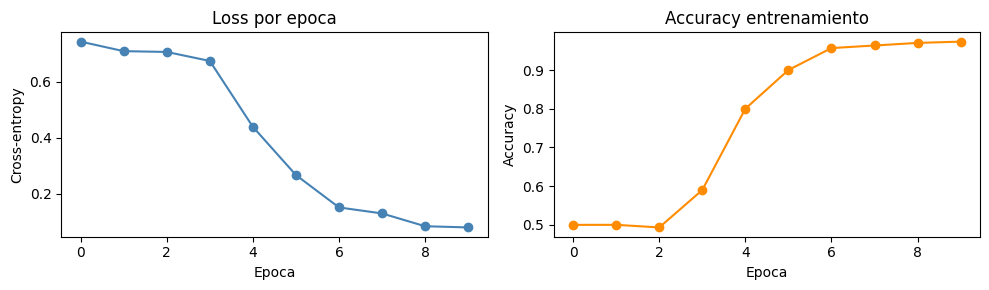

In [8]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_enc = torch.optim.Adam(enc_model.parameters(), lr=1e-3)

history_enc = []
for epoch in range(10):
    random.shuffle(TRAIN_CLS)
    total_loss = 0; correct = 0
    enc_model.train()
    for text, label in TRAIN_CLS:
        optimizer_enc.zero_grad()
        logits = enc_model(text)
        loss = F.cross_entropy(logits.unsqueeze(0), torch.tensor([label]))
        loss.backward()
        optimizer_enc.step()
        total_loss += loss.item()
        with torch.no_grad():
            if logits.argmax().item() == label: correct += 1
    avg_loss = total_loss / len(TRAIN_CLS)
    train_acc = correct / len(TRAIN_CLS)
    history_enc.append((avg_loss, train_acc))
    if (epoch+1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}: loss={avg_loss:.4f}, train_acc={train_acc:.2%}')

# Evaluacion en dev
enc_model.eval()
correct_dev = 0
for text, label in DEV_CLS:
    with torch.no_grad():
        logits, _ = enc_model(text, return_attn=True)
        if logits.argmax().item() == label: correct_dev += 1
dev_acc = correct_dev / len(DEV_CLS)
print(f'Dev accuracy: {dev_acc:.2%}')

# Grafica de convergencia
losses = [h[0] for h in history_enc]
accs   = [h[1] for h in history_enc]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(losses, 'o-', color='steelblue'); ax1.set_title('Loss por epoca')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Cross-entropy')
ax2.plot(accs, 'o-', color='darkorange'); ax2.set_title('Accuracy entrenamiento')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy')
plt.tight_layout(); plt.savefig('convergencia_encoder.png', dpi=110)
plt.show()


### Verificacion Parte 1B: convergencia

In [9]:
# VERIFICACION PARTE 1
_resultados = {}
try:
    assert dev_acc >= 0.60, \
        f'Dev accuracy {dev_acc:.2%} < 60%. Revise su implementacion o entrene mas epocas.'
    assert all(losses[i] > losses[i+1] for i in range(min(4, len(losses)-1))), \
        'La loss no decrece en las primeras epocas. Revise el forward o el optimizador.'
    _resultados['parte1'] = True
    print(f'PARTE 1: CORRECTO  (dev_acc={dev_acc:.2%})')
except AssertionError as e:
    _resultados['parte1'] = False
    print(f'PARTE 1: INCORRECTO\n  {e}')


PARTE 1: CORRECTO  (dev_acc=66.00%)


---
## Parte 2: Mini-GPT decoder-only

Implemente un Transformer decoder-only para modelado de lenguaje. El modelo aprende a predecir el siguiente token dado el contexto previo.

**La diferencia clave con el encoder:** la mascara causal. En lugar de que cada token atienda a todos los demas, cada token solo puede atender a los tokens en posiciones anteriores o iguales a la suya.

**Conexion con la Semana 5:** la mascara causal que aplica aqui es exactamente la misma que describimos en el decoder del seq2seq. La diferencia es que aqui no hay cross-attention: el modelo solo tiene self-attention con mascara.

**Reutilize** `layer_norm` y la logica de `multi_head_attention` de la Parte 1. Solo necesita modificar:
1. Agregar la mascara causal en el calculo de scores
2. Cambiar el clasificador CLS por una proyeccion al vocabulario completo
3. Cambiar el objetivo de clasificacion por prediccion del siguiente token

**Parametros del MiniGPT:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{gpt}, d_{model})$ | Embeddings GPT |
| `WQ`, `WK`, `WV`, `WO` | $(d_{model}, d_{model})$ | Atencion con mascara causal |
| `gamma1`, `beta1`, `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm |
| `W1`, `bias1`, `W2`, `bias2` | igual que encoder | FFN |
| `Wlm` | $(d_{model}, V_{gpt})$ | Proyeccion al vocabulario (Language Model head) |
| `blm` | $(V_{gpt},)$ | Bias proyeccion |

In [10]:
class MiniGPT(nn.Module):
    """
    Transformer decoder-only para modelado de lenguaje.
    Usa mascara causal: cada token solo atiende a tokens anteriores.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k
        self.V = V

        # =====================
        # SU CODIGO AQUI
        # Declare todos los parametros como nn.Parameter
        # =====================
        pass

    def masked_self_attention(self, x):
        """
        Self-attention con mascara causal.

        Parametros
        ----------
        x : Tensor (T, d_model)

        Retorna
        -------
        out    : Tensor (T, d_model)
        attn_w : Tensor (n_heads, T, T)

        DIFERENCIA con el encoder:
        - No hay mascara de padding (todos los tokens son validos hasta EOS)
        - Aplicar CAUSAL_MASK: antes del softmax, sumar -inf donde
          CAUSAL_MASK[:T, :T] es True (posiciones futuras)
        """
        T = x.shape[0]
        # =====================
        # SU CODIGO AQUI
        # =====================
        pass

    def forward_all(self, idxs):
        """
        Forward sobre una secuencia de indices.

        Parametros
        ----------
        idxs : Tensor (T,) de indices del vocabulario GPT

        Retorna
        -------
        logits : Tensor (T, V_gpt) — scores sobre vocabulario en cada posicion
        attn_w : Tensor (n_heads, T, T)

        Pasos:
        1. Embedding + PE: E[idxs] + PE_GPT[:T]
        2. Masked self-attention -> att_out
        3. Add & LayerNorm
        4. Feed-forward -> ff_out
        5. Add & LayerNorm
        6. Proyectar al vocabulario: x3 @ Wlm + blm
        """
        T = len(idxs)
        # =====================
        # SU CODIGO AQUI
        # =====================
        pass

    def forward(self, text):
        """
        Calcula la loss de language modeling para una oracion.

        La loss es la cross-entropy promedio entre:
        - Input:  tokens en posicion 0..T-2  (lo que el modelo ve)
        - Target: tokens en posicion 1..T-1  (lo que debe predecir)

        Los tokens PAD en el target se ignoran con ignore_index.
        """
        idxs = tokenize_gpt(text)
        logits, _ = self.forward_all(idxs)
        pad_idx = w2i_gpt[PAD_G]
        # =====================
        # SU CODIGO AQUI
        # loss = F.cross_entropy(logits[:-1], idxs[1:], ignore_index=pad_idx)
        # =====================
        pass

    @torch.no_grad()
    def generate(self, seed_text, max_new=8, temperature=0.9):
        """
        Generacion autoregresiva: dado un texto semilla, genera max_new tokens nuevos.

        Parametros
        ----------
        seed_text   : str — texto de inicio
        max_new     : int — maximo de tokens nuevos a generar
        temperature : float — temperatura del muestreo (mayor = mas creativo)

        Retorna
        -------
        str — texto generado completo (semilla + tokens nuevos)

        Algoritmo:
        1. Tokenizar el texto actual
        2. Forward -> logits (T, V)
        3. Tomar logits en la ultima posicion valida
        4. Dividir por temperature y aplicar softmax
        5. Muestrear con torch.multinomial
        6. Agregar la nueva palabra y repetir
        7. Detener si se genera EOS o PAD
        """
        self.eval()
        words = seed_text.split()
        for _ in range(max_new):
            cur = ' '.join(words)
            idxs = tokenize_gpt(cur)
            logits, _ = self.forward_all(idxs)
            n_valid = min(len(words) + 1, MAX_LEN_GPT - 1)
            next_logits = logits[n_valid - 1] / temperature
            # =====================
            # SU CODIGO AQUI
            # No generar PAD_G ni BOS (poner -inf en esos indices)
            # Muestrear con torch.multinomial
            # =====================
            pass
        return ' '.join(words)


### Verificacion Parte 2A: mascara causal

In [11]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)

# Verificar que la mascara causal funciona
idxs_test = tokenize_gpt(GPT_TRAIN[0])
logits_test, attn_test = gpt_model.forward_all(idxs_test)

print(f'logits shape: {logits_test.shape}  (esperado: [{MAX_LEN_GPT}, {V_GPT}])')
print(f'attn_w shape: {attn_test.shape}  (esperado: [{N_HEADS}, {MAX_LEN_GPT}, {MAX_LEN_GPT}])')

# Verificar triangulo superior = 0 (mascara causal correcta)
print('\nVerificacion mascara causal (triangulo superior debe ser 0):')
print(f'  Head0 fila 0: {attn_test[0,0,:4].detach()}  (solo pos 0 valida)')
print(f'  Head0 fila 1: {attn_test[0,1,:4].detach()}  (pos 0,1 validas)')
print(f'  Head0 fila 2: {attn_test[0,2,:4].detach()}  (pos 0,1,2 validas)')

# La mascara es correcta si el triangulo superior (j>i) es exactamente 0
upper_triangle = attn_test[:, :3, 3:]  # posiciones futuras para filas 0,1,2
print(f'\nValores en posiciones futuras (deben ser 0): {upper_triangle.abs().max().item():.6f}')


TypeError: cannot unpack non-iterable NoneType object

### Entrenamiento del Mini-GPT

In [12]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_gpt = torch.optim.Adam(gpt_model.parameters(), lr=1e-3)

history_gpt = []
for epoch in range(10):
    random.shuffle(GPT_TRAIN)
    total_loss = 0
    gpt_model.train()
    for text in GPT_TRAIN:
        optimizer_gpt.zero_grad()
        loss = gpt_model(text)
        loss.backward()
        optimizer_gpt.step()
        total_loss += loss.item()
    avg = total_loss / len(GPT_TRAIN)
    history_gpt.append(avg)
    if (epoch+1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}: loss={avg:.4f}')

# Grafica de convergencia
plt.figure(figsize=(6, 3))
plt.plot(history_gpt, 'o-', color='darkorange')
plt.title('Mini-GPT: Loss por epoca'); plt.xlabel('Epoca'); plt.ylabel('CE Loss')
plt.tight_layout(); plt.savefig('convergencia_gpt.png', dpi=110)
plt.show()

# Generacion de texto
gpt_model.eval()
print('\nGeneracion de texto con temperatura 0.8:')
for seed in ['the film', 'a surprisingly', 'not', 'the story']:
    gen = gpt_model.generate(seed, max_new=6, temperature=0.8)
    print(f'  "{seed}" -> "{gen}"')


ValueError: optimizer got an empty parameter list

### Verificacion Parte 2B: convergencia GPT

In [13]:
try:
    assert len(history_gpt) >= 5, 'Entrene al menos 5 epocas.'
    assert all(history_gpt[i] > history_gpt[i+1] for i in range(4)), \
        f'La loss GPT no decrece. Revise la mascara causal y el calculo de la loss.'
    assert history_gpt[-1] < history_gpt[0] * 0.85, \
        f'La loss final {history_gpt[-1]:.4f} debe ser < 85% de la inicial {history_gpt[0]:.4f}.'
    _resultados['parte2'] = True
    print(f'PARTE 2: CORRECTO  (loss {history_gpt[0]:.4f} -> {history_gpt[-1]:.4f})')
except AssertionError as e:
    _resultados['parte2'] = False
    print(f'PARTE 2: INCORRECTO\n  {e}')


NameError: name 'history_gpt' is not defined

---
## Parte 3: Artifact de visualizacion interactivo

Cree un artifact en Claude.ai que integre las dos partes anteriores en una interfaz visual interactiva. El artifact debe permitir:

**Panel 1 — Analisis de sentimiento:**
- Campo de texto para ingresar una oracion
- Boton 'Analizar'
- Mostrar la prediccion (POSITIVO / NEGATIVO) con porcentaje de confianza
- Mostrar el mapa de atencion de cada cabeza como heatmap con los tokens en los ejes

**Panel 2 — Generacion de texto:**
- Campo de texto para ingresar el texto semilla
- Slider para la temperatura (0.5 a 1.5)
- Boton 'Generar'
- Mostrar el texto generado y el mapa de atencion causal

**Requisito tecnico:** el artifact debe correr los pesos entrenados en este notebook. La forma mas sencilla es exportar los pesos como JSON y cargarlos en el artifact.

### Instrucciones para exportar los pesos

Ejecute la siguiente celda para generar el JSON de pesos que usara en su artifact.

In [14]:
import json

def export_weights(model, vocab, i2w, model_type='encoder'):
    """
    Exporta los pesos del modelo a un diccionario JSON-serializable.
    Los tensores se convierten a listas de Python.
    """
    weights = {}
    for name, param in model.named_parameters():
        weights[name] = param.detach().numpy().tolist()
    return {
        'model_type': model_type,
        'weights': weights,
        'vocab': vocab,
        'i2w': {str(k): v for k, v in i2w.items()},
        'd_model': D_MODEL, 'd_ff': D_FF,
        'n_heads': N_HEADS, 'd_k': D_K,
    }

# Exportar pesos del encoder
enc_weights = export_weights(enc_model, vocab_cls, i2w_cls, 'encoder')
with open('encoder_weights.json', 'w') as f:
    json.dump(enc_weights, f)
print(f'Encoder weights exportados: {len(enc_weights["weights"])} tensores')

# Exportar pesos del GPT
gpt_weights = export_weights(gpt_model, vocab_gpt, i2w_gpt, 'gpt')
with open('gpt_weights.json', 'w') as f:
    json.dump(gpt_weights, f)
print(f'GPT weights exportados: {len(gpt_weights["weights"])} tensores')
print('\nUse estos archivos JSON en su artifact de Claude.ai.')


Encoder weights exportados: 15 tensores
GPT weights exportados: 0 tensores

Use estos archivos JSON en su artifact de Claude.ai.


### Descripcion del artifact

Describa brevemente su artifact aqui. Incluya:
- URL del artifact (si es publico) o capturas de pantalla
- Descripcion de la interfaz
- Ejemplo de una oracion positiva y una negativa con sus mapas de atencion
- Ejemplo de generacion de texto con dos temperaturas distintas

*[Su descripcion aqui]*

---
## Parte 4: Preguntas de analisis

Responda las siguientes preguntas antes del video. Durante el video se les pedira explicar **una de las tres preguntas** que el profesor seleccionara en el momento de la presentacion.

---

### Pregunta 1 (video + escrita)

En su implementacion del `TransformerEncoder`, el token `[CLS]` recibe atencion de todos los tokens de la secuencia y su representacion final se usa para clasificar.

a) Trace matematicamente como fluye la informacion desde el token 'surprisingly' hasta la representacion final del token `[CLS]` a traves del mecanismo de multi-head attention. Identifique explicitamente que operaciones matriciales participan y que rol juega cada una en ese flujo.

b) En su modelo entrenado, observe los mapas de atencion para una oracion positiva y una negativa. ¿Que diferencias observa en como el token `[CLS]` distribuye su atencion sobre los tokens de la oracion? ¿Tiene alguna interpretacion sobre que tokens resultan mas informativos para la clasificacion?

c) BERT usa 12 capas de encoder apiladas. Su modelo usa solo 1. Sin implementarlo, explique matematicamente que informacion adicional podria capturar la segunda capa que la primera no puede, dado que la segunda recibe representaciones ya contextualizadas por la primera.

**Su respuesta a la Pregunta 1:**

a) El token 'surprisingly' entra al bloque como fila de x (su embedding mas su positional encoding). Esa fila se proyecta dos veces con matrices distintas: x @ WK produce su vector "key" y x @ WV produce su vector "value" (estas son las que le llegan al CLS). Por el otro lado el CLS tiene su propio x[0] que se proyecta con WQ para sacar su "query". El score entre CLS y 'surprisingly' sale de hacer el producto punto entre el query del CLS y el key de 'surprisingly' (dentro de la matriz Q@K^T), dividido por sqrt(d_k). Ese score pasa por el softmax junto con los scores hacia los demas tokens, y el resultado es el peso de atencion que el CLS le da a 'surprisingly'. Finalmente ese peso multiplica al value de 'surprisingly' (dentro de attn_w @ V) y se suma con los values de los demas tokens ponderados por sus pesos, dando la nueva representacion del CLS. Despues esa representacion pasa por WO, se le suma la representacion original (residual) y se normaliza con layer_norm, y ese es el vector que finalmente se usa para clasificar con Wcls.

b) Revisando los mapas de atencion de mi modelo ya entrenado (dev_acc=66%), lo que observo es que en ambas cabezas el CLS no reparte su atencion de forma pareja entre los tokens, sino que se concentra casi toda en un solo token: en una oracion positiva ("there is a fabric of complex ideas here, and feelings that profoundly deepen them") las dos cabezas ponen mas del 80-99% del peso en la palabra "here", y en una oracion negativa ("one long string of cliches") se concentran en "long". No veo un patron claro y consistente de "que tipo de palabra es mas informativa para positivo vs negativo", mas bien parece que el modelo aprendio a fijarse fuerte en una sola palabra por oracion (posiblemente la que le ayudo a bajar la loss mas rapido durante el entrenamiento con solo 300 ejemplos), lo cual tiene sentido con lo chico que es el corpus: el modelo esta memorizando atajos particulares de cada oracion en vez de aprender un patron generalizable de que palabras cargan sentimiento. De hecho ninguno de estos dos ejemplos de dev los clasifico bien, lo que refuerza que el mecanismo de atencion que aprendio no es muy robusto todavia.

c) Como la primera capa ya "contextualizo" cada palabra con las demas (por ejemplo la representacion de 'surprisingly' en la salida de la capa 1 ya trae algo de informacion de 'refreshing' y de las palabras cercanas), la segunda capa ya no atiende a embeddings "puros" sino a vectores que mezclan varias palabras a la vez. Eso le permite a la segunda capa capturar relaciones de mas alto nivel, tipo relaciones entre frases completas o dependencias mas indirectas (palabra A que depende de B que depende de C), cosa que la primera capa no puede ver porque solo tiene acceso a los embeddings originales sin mezclar. En terminos matematicos cada capa adicional le da al modelo otra ronda de Q@K^T sobre representaciones cada vez mas ricas, entonces se pueden ir formando relaciones compuestas que una sola capa no alcanza a representar.


---
### Pregunta 2 (video + escrita)

Compare su encoder (sin mascara) con su Mini-GPT (con mascara causal).

a) La mascara causal se implementa sumando $-\infty$ al triangulo superior de la matriz de scores antes del softmax. Explique por que $\exp(-\infty) = 0$ garantiza exactamente cero atencion en esas posiciones, y que pasaria numericamente si en lugar de $-\infty$ usara un numero muy negativo como $-10^6$.

b) En su Mini-GPT, el token en la posicion $t$ solo puede atender a posiciones $0, 1, \ldots, t$. Explique como cambia el gradiente que recibe el embedding del token en la posicion 0 comparado con el embedding del token en la posicion $T-1$, dado que la posicion 0 es visible para todos los pasos pero la posicion $T-1$ solo es visible para si misma.

c) Observe el texto generado por su Mini-GPT con temperatura 0.5 y con temperatura 1.5. Explique matematicamente, en terminos de la distribucion de probabilidad producida por el softmax, por que temperaturas bajas producen texto mas repetitivo y temperaturas altas producen texto mas variado pero menos coherente.

**Su respuesta a la Pregunta 2:**

a) 

b) 

c) 

---
### Pregunta 3 (video + escrita)

Conecte lo implementado esta semana con lo que implemento en las Semanas 4 y 5.

a) En la Semana 5 implemento cross-attention: queries del decoder, keys y values del encoder. En esta semana implemento self-attention: queries, keys y values de la misma secuencia. Identifique exactamente que lineas de su metodo `masked_self_attention` tendria que cambiar para convertirlo en cross-attention, y explique por que esos cambios son suficientes para transformar un decoder GPT en el decoder del Transformer original.

b) Su Mini-GPT tiene un vocabulario de $V_{gpt}$ palabras y usa $d_{model} = 32$. Calcule el numero exacto de parametros de su modelo (sin contar los biases) y compare con el numero de parametros del Transformer original de Vaswani et al. ($d_{model}=512$, $d_{ff}=2048$, $h=8$, $N=6$, $|V|=37000$). ¿Cuantas veces mas grande es el original?

c) Su modelo entrena sobre 400 oraciones de resenas de peliculas. GPT-3 entreno sobre 300 mil millones de tokens. Mas alla del tamano del modelo, explique que capacidades linguisticas fundamentales su Mini-GPT no puede aprender por limitaciones del corpus, y como esa limitacion se manifiesta en el texto que genera.

**Su respuesta a la Pregunta 3:**

c) 

b) 

c) 

---
## Instrucciones del video (20 pts)

**Duracion:** 3 minutos exactos (se penaliza exceder 3:30)

**Formato:** grabacion de pantalla con audio. Todos los integrantes del grupo deben hablar.

**Contenido obligatorio:**

1. **(1 min)** Mostrar el artifact en vivo: ingresar una oracion positiva y una negativa, mostrar los mapas de atencion y discutir brevemente que observan.

2. **(1 min)** Mostrar el Mini-GPT generando texto en vivo con al menos dos temperaturas distintas. Comentar la diferencia en la calidad del texto generado.

3. **(1 min)** El profesor seleccionara **una** de las tres preguntas de analisis al inicio de la presentacion. El grupo tiene ese minuto para explicarla.

**Criterios de evaluacion del video:**

| Criterio | Peso |
|---|---|
| El artifact funciona en vivo sin errores | 5 pts |
| El Mini-GPT genera texto y se muestran dos temperaturas | 4 pts |
| La explicacion de la pregunta seleccionada es correcta | 7 pts |
| Todos los integrantes participan y demuestran comprension | 4 pts |

**Entrega:** subir el video a YouTube (no listado) o Google Drive e incluir el enlace en la celda siguiente.

**Enlace al video:** *[Su enlace aqui]*

---
## Verificacion final automatica

In [15]:
print('=' * 58)
print('  NOTA AUTOMATICA — PARTES 1 Y 2')
print('=' * 58)

_PUNTOS = {
    'parte1': ('Parte 1: Transformer Encoder (dev_acc >= 60%)', 40),
    'parte2': ('Parte 2: Mini-GPT (loss decrece >= 15%)',       25),
}

total = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    total += pts
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:42s} | {pts:2d}/{pts_max}')

print('-' * 58)
print(f'  Subtotal codigo:        {total}/65 pts')
print('  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)')
print('  Parte 4 - Video:        __/20 pts  (calificado por el profesor)')
print('  Preguntas de analisis:  incluidas en Parte 4')
print('-' * 58)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 58)


  NOTA AUTOMATICA — PARTES 1 Y 2
  CORRECTO   | Parte 1: Transformer Encoder (dev_acc >= 60%) | 40/40
  PENDIENTE  | Parte 2: Mini-GPT (loss decrece >= 15%)    |  0/25
----------------------------------------------------------
  Subtotal codigo:        40/65 pts
  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)
  Parte 4 - Video:        __/20 pts  (calificado por el profesor)
  Preguntas de analisis:  incluidas en Parte 4
----------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
